# 실습 13: 답안지를 덮고 풀어보기
- 상황: 검사 결과가 없는 라인이 들어온다. 답 없이 이상한 것을 찾을 수 있나
- 목표: 정답 열을 가리고 이상을 지목한 뒤, 마지막에만 답을 꺼내 채점한다

## Step 0. 정제본 불러오기

In [1]:
import pandas as pd

df = pd.read_csv('../../day02/lab06_clean-dataset/results/secom_clean.csv')

sensor_cols = [c for c in df.columns if c.startswith('sensor_')]
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

X = df[sensor_cols]

# 아래에서는 쓰지 않지만, 나중에 맞춰볼 때 쓰려고 따로 만들어 둔다
y = (df['result'] == '불량').astype(int)

print('전체 행 수:', X.shape[0])
print('센서 열 개수:', X.shape[1])
print('불량 건수:', int(y.sum()))
print('불량 비율:', round(y.mean() * 100, 2), '%')

전체 행 수: 1567
센서 열 개수: 50
불량 건수: 104
불량 비율: 6.64 %


## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 답 없이 찾는 말

| 수업에서 쓰는 말 | 정식 이름 | 뜻 |
|---|---|---|
| 지도학습 | supervised learning | 정답이 붙어 있는 기록으로 배우는 것. 나흘 동안 한 것이 전부 이것 |
| 비지도학습 | unsupervised learning | 정답 없이 데이터의 생김새만 보고 하는 것. 오늘 넘는 선 |
| 이상탐지 | anomaly detection | 다수와 다른 것을 찾아내는 일. 정답 대신 동료들과 비교한다 |
| 고립시키기 | 아이솔레이션 포레스트 (Isolation Forest) | 몇 번 잘라야 그 줄만 혼자 남나를 보는 방법. 빨리 혼자가 되면 이상 |
| 이상 비율 | contamination | 전체 중 몇 %를 이상으로 볼지 사람이 정해주는 값 |

가운데 칸이 진짜 이름이다. 코드와 면접에서는 이쪽을 쓴다.

## Step 2. 답을 가리고 이상한 것 지목하기

In [ ]:
# 다수와 다른 줄을 찾아주는 도구를 불러온다
from sklearn.ensemble import IsolationForest

# ① 바로 위에서 불러온 도구 이름을 그대로 쓴다
# ② 전체의 몇 %를 이상으로 볼지 내가 정해서 넣는 자리. 0.05 는 5%
# ③ 다시 돌려도 같은 결과가 나오게 번호를 고정하는 자리 - 지난주에도 썼다
탐지기 = IsolationForest(contamination=0.05, random_stste=42)
# ④ 정답은 넣지 않는다 - 센서 값만 담긴 것을 넣는다. 이것이 오늘의 핵심
지목 = 탐지기.fit_predict(X)

# ⑤ 돌려주는 값은 두 가지뿐이다. 이상이면 무엇으로 나오나
print("이상이라 지목한 건수:", (지목 == -1).sum())
print("전체 건수:", len(X))

이상이라 지목한 건수: 79
전체 건수: 1567


### 문법 노트 - 답 없이 지목하기

| 밑줄 | 넣은 것 | 하는 일 | 새로 배운 것인가 |
|---|---|---|---|
| ① | `IsolationForest` | 몇 번 잘라야 혼자 남는지로 이상을 찾는 도구 | 새로 배움 |
| ② | `contamination` | 전체의 몇 %를 이상으로 볼지 정하는 자리 | 새로 배움 |
| ③ | `random_state` | 다시 돌려도 같게 나오도록 고정하는 번호 | 나눌 때·모델 만들 때 계속 썼다 |
| ④ | `X` | 센서 값만 담긴 것. 정답은 안 들어간다 | 계속 쓴 이름 |
| ⑤ | `-1` | 이상이라는 표시 (정상은 `1`) | 새로 배움 · 0과 1이 아니다 |

## Step 4. 답을 꺼내 채점하기

In [ ]:
# ⑥ 지목이 이상인 자리만 참이 되는 표시를 만든다
이상표시 = (지목 == -1)

# 맨 위에서 만들어 둔 불량 여부(y)를 여기서 처음 꺼내 쓴다
정답 = y

# ⑦ 두 표시가 둘 다 참인 자리만 남기는 기호
# ⑧ 불량을 무엇으로 적어뒀는지
# ⑨ 참인 자리가 몇 개인지 세는 것
잡은것 = (이상표시 & (정답 == 1)).sum()

# 지목 중 진짜 비율 = 잡은 것 나누기 지목한 건수
지목중진짜 = 잡은것 / 이상표시.sum()

# 전체 불량 중 잡은 비율 = 잡은 것 나누기 전체 불량 건수
전체중잡은것 = 잡은것 / (정답 == 1).sum()

print("지목", 이상표시.sum(), "건 / 그중 불량", 잡은것, "건")
print("지목 중 진짜:", round(지목중진짜 * 100, 1), "%")
print("전체 불량 중 잡은 것:", round(전체중잡은것 * 100, 1), "%")

지목 79 건 / 그중 불량 12 건
지목 중 진짜: 15.2 %
전체 불량 중 잡은 것: 11.5 %


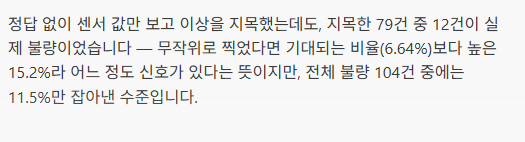

### 문법 노트 - 채점할 때 쓴 것

| 밑줄 | 넣은 것 | 하는 일 | 새로 배운 것인가 |
|---|---|---|---|
| ⑥ | `-1` | 이 도구가 쓰는 이상 표시 | 위에서 한 번 나왔다 |
| ⑦ | `&` | 양쪽이 다 참인 자리만 참 | 새로 배움 |
| ⑧ | `1` | 불량을 1로 적어둔 그 값 | 사흘째 쓰는 약속 |
| ⑨ | `.sum()` | 참인 자리의 개수를 센다 | 참·거짓에 쓰면 개수가 나온다 |

## Step 5. 아무 근거 없이 찍었다면

In [4]:
# 이상탐지 없이, IsolationForest가 지목한 것과 같은 건수(79건)만큼 그냥 무작위로 뽑아본다
무작위지목 = y.sample(n=79, random_state=42)

무작위중진짜 = int((무작위지목 == 1).sum())
무작위지목중진짜비율 = round(무작위중진짜 / len(무작위지목) * 100, 1)

print("무작위로 고른", len(무작위지목), "건 중 불량:", 무작위중진짜, "건")
print("무작위 지목 중 진짜 비율:", 무작위지목중진짜비율, "%")
print("전체 불량률:", round(y.mean() * 100, 2), "%")

무작위로 고른 79 건 중 불량: 5 건
무작위 지목 중 진짜 비율: 6.3 %
전체 불량률: 6.64 %


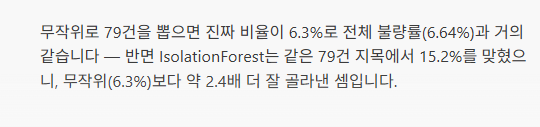

## Step 6. 오늘 알게 된 것

| 고른 방법 | 지목 건수 | 그중 불량 | 지목 중 진짜 |
|---|---|---|---|
| 아무 근거 없이 | [79] | [5] | [6.3%] |
| 고립시키기 (5%) | [79] | [12] | [15.2%] |

- 정답을 안 쓰고 얻은 것 : [같은 79건을 고르는데 불량이 두 배 넘게 들어 있었다]
- 아직 못 미더운 점 : [전체 불량 104건 중 12건만 잡았다. 92건은 그대로 지나갔다]
- 이 결과를 어디에 쓸 수 있나 : [먼저 열어볼 순서를 정하는 데. 불량 판정으로 쓰면 안 된다]

---
## 직접 해보기 (도전) - 몇 %로 볼 것인가

- 상황: 5%로 봤는데, 2%나 10%로 하면 어떻게 될까
- 할 일: 이상 비율을 바꿔가며 지목 건수와 적중을 비교한다
- 결과물: 네 줄짜리 표 1개 + 한 줄 메모

### 1단. 문턱을 바꿔보기

In [5]:
# 이상 비율(contamination)만 바꿔가며 같은 방식으로 지목하고, 정답은 채점할 때만 꺼내 쓴다
결과_비율 = []
for 비율 in [0.02, 0.05, 0.10, 0.15]:
    탐지기_n = IsolationForest(contamination=비율, random_state=42)
    지목_n = 탐지기_n.fit_predict(X)  # 지목할 때는 X만 넣는다

    이상표시_n = (지목_n == -1)
    잡은것_n = int((이상표시_n & (정답 == 1)).sum())

    지목중진짜_n = 잡은것_n / 이상표시_n.sum() * 100
    전체중잡은것_n = 잡은것_n / (정답 == 1).sum() * 100

    결과_비율.append({
        '이상 비율': 비율,
        '지목 건수': int(이상표시_n.sum()),
        '그중 불량': 잡은것_n,
        '지목 중 진짜': round(지목중진짜_n, 1),
        '전체 불량 중 잡은 것': round(전체중잡은것_n, 1),
    })

비율비교표 = pd.DataFrame(결과_비율).set_index('이상 비율')
비율비교표

,지목 건수,그중 불량,지목 중 진짜,전체 불량 중 잡은 것
이상 비율,,,,
0.02,32,8,25.0,7.7
0.05,79,12,15.2,11.5
0.10,157,22,14.0,21.2
0.15,235,37,15.7,35.6


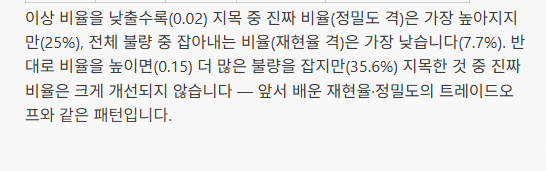

### 문턱을 바꾸면

| 이상 비율 | 지목 건수 | 지목 중 진짜 | 전체 중 잡은 것 |
|---|---|---|---|
| 2% | [32] | [25.0%] | [7.7%] |
| 5% | [79] | [15.2%] | [11.5%] |
| 10% | [157] | [14.0%] | [21.2%] |
| 15% | [235] | [15.7%] | [35.6%] |

- 알게 된 것 : [많이 지목할수록 전체 불량 중 잡는 비율은 오르는데, 지목 중 진짜 비율은 25%에서 14%로 떨어진다. 지난주에 문턱을 옮길 때와 같은 모양이다]

### 2단. 얼마나 이상한지 순서 매기기

In [6]:
# score_samples - 다시 학습시키지 않고, 이미 학습된 탐지기(이상 비율 0.05)에 X를 넣어 이상 점수만 뽑는다
이상점수 = 탐지기.score_samples(X)

# 점수가 낮을수록 이상하다는 말이 맞는지, 지목(-1/1) 두 그룹의 평균 점수로 확인한다
print("이상(-1)으로 지목된 것의 평균 점수:", round(이상점수[지목 == -1].mean(), 4))
print("정상(1)으로 지목된 것의 평균 점수:", round(이상점수[지목 == 1].mean(), 4))

이상(-1)으로 지목된 것의 평균 점수: -0.5176
정상(1)으로 지목된 것의 평균 점수: -0.3958


In [7]:
# 점수가 낮은 순(가장 이상한 순)으로 자리 번호를 정렬한다
이상한순서 = 이상점수.argsort()

결과_상위 = []
for N in [20, 50, 79]:
    상위인덱스 = 이상한순서[:N]
    상위중불량 = int(정답.iloc[상위인덱스].sum())
    결과_상위.append({
        '상위 건수': N,
        '그중 불량': 상위중불량,
        '적중률(%)': round(상위중불량 / N * 100, 1),
    })

상위비교표 = pd.DataFrame(결과_상위).set_index('상위 건수')
상위비교표

,그중 불량,적중률(%)
상위 건수,,
20,6,30.0
50,9,18.0
79,12,15.2


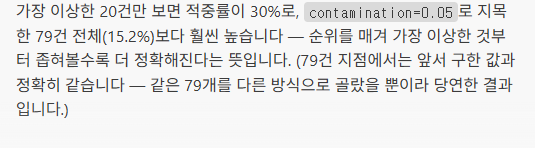

### 가장 이상한 것부터 열어본다면

| 상위 몇 건 | 그중 불량 | 지목 중 진짜 |
|---|---|---|
| 20건 | [6] | [30.0%] |
| 50건 | [9] | [18.0%] |
| 79건 | [12] | [15.2%] |

- 알게 된 것 : [위에서부터 열어볼수록 적중이 높다. 상위 20건은 30.0%로 79건 전체(15.2%)의 두 배다]